동국대학교 학생을 위한 자취 지역 분석

In [51]:
################################################
#동국대학교 학생이 살기 좋은 자취 지역을 월세 데이터를 통해 분석
#접근성 및 가격을 고려한 통합 가성비 지역 산출
#2026년 6월
#서울 열린 데이터 광장의 2025년 서울 특별시_전월세가 데이터 활용
###################################################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import requests

In [40]:
from pathlib import Path

file_path = Path(r'..\..\..\Downloads\서울특별시_전월세가_2025\서울특별시_전월세가_2025.csv')
if not file_path.exists():
    file_path = Path.home() / 'Downloads' / '서울특별시_전월세가_2025' / '서울특별시_전월세가_2025.csv'

try:
    df = pd.read_csv(file_path, encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv(file_path, encoding='cp949')

print("✓ 파일 로드 성공")
print("실제 파일 컬럼명:", df.columns.tolist())
print(f"데이터 크기: {df.shape}")

✓ 파일 로드 성공
실제 파일 컬럼명: ['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번', '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도', '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료']
데이터 크기: (1084942, 23)


In [48]:
target = ['중구', '성북구', '동대문구', '성동구']

df['자치구명'] = df['자치구명'].astype(str).str.strip()
df['전월세구분'] = df['전월세구분'].astype(str).str.strip()


dataset = df[
    (df['자치구명'].isin(target)) &
    (df['전월세구분'] == '월세')
].dropna(subset=['자치구명', '전월세구분'])

print(f"✓ 필터링 완료: {len(dataset)}개 행")
print(dataset.head())

✓ 필터링 완료: 80600개 행
    접수년도    자치구코드  자치구명    법정동코드   법정동명  지번구분코드 지번구분      본번    부번     층  ...  \
4   2025  11290.0   성북구  13400.0    길음동     1.0   대지  1284.0   0.0  19.0  ...   
5   2025  11290.0   성북구  13400.0    길음동     1.0   대지  1284.0   0.0  19.0  ...   
7   2025  11290.0   성북구  12300.0  안암동3가     1.0   대지   138.0   0.0  12.0  ...   
50  2025  11230.0  동대문구  10900.0    휘경동     1.0   대지   380.0   0.0  12.0  ...   
75  2025  11200.0   성동구  10500.0    마장동     1.0   대지   797.0  63.0   2.0  ...   

    임대료(만원)             건물명    건축년도   건물용도         계약기간 신규계약구분  갱신청구권사용  \
4       105   길음뉴타운8단지(래미안)  2010.0    아파트  26.02~28.02     갱신      NaN   
5       115   길음뉴타운8단지(래미안)  2010.0    아파트  26.02~28.02     갱신      NaN   
7        45       해링턴플레이스안암  2024.0    아파트  26.01~27.01     신규      NaN   
50       12  회기역하트리움역세권청년주택  2023.0    아파트  26.02~28.02     신규      NaN   
75       95        (797-63)  2002.0  연립다세대  26.02~28.02     신규      NaN   

      종전보증금 종전임대료   면적당_임대료  
4   40000.0  

In [27]:
print("✓ 사용 가능한 컬럼:", df.columns.tolist())
required_cols = ['자치구명', '법정동명', '전월세구분', '임대료(만원)', '건축년도']
available_cols = [col for col in required_cols if col in df.columns]

✓ 사용 가능한 컬럼: ['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번', '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도', '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료']


In [28]:
print(f"✓ 실제 사용할 컬럼: {available_cols}")
dataset = dataset[available_cols].copy()
dataset['임대료(만원)'] = pd.to_numeric(dataset['임대료(만원)'], errors='coerce')
dataset = dataset.dropna(subset=['임대료(만원)'])
print(f"✓ 시각화용 데이터 행 수: {len(dataset)}")

✓ 실제 사용할 컬럼: ['자치구명', '법정동명', '전월세구분', '임대료(만원)', '건축년도']
✓ 시각화용 데이터 행 수: 80600


✓ 이상치 제거 전 행 수: 1084942
✓ 이상치 제거 후 행 수: 1070945
✓ IQR 기준 범위: -3.2166 ~ 5.3610


C:\Users\kimjy\AppData\Local\Temp\ipykernel_34636\2135412706.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_unit_price, y='법정동명', x='면적당_임대료', palette='viridis')


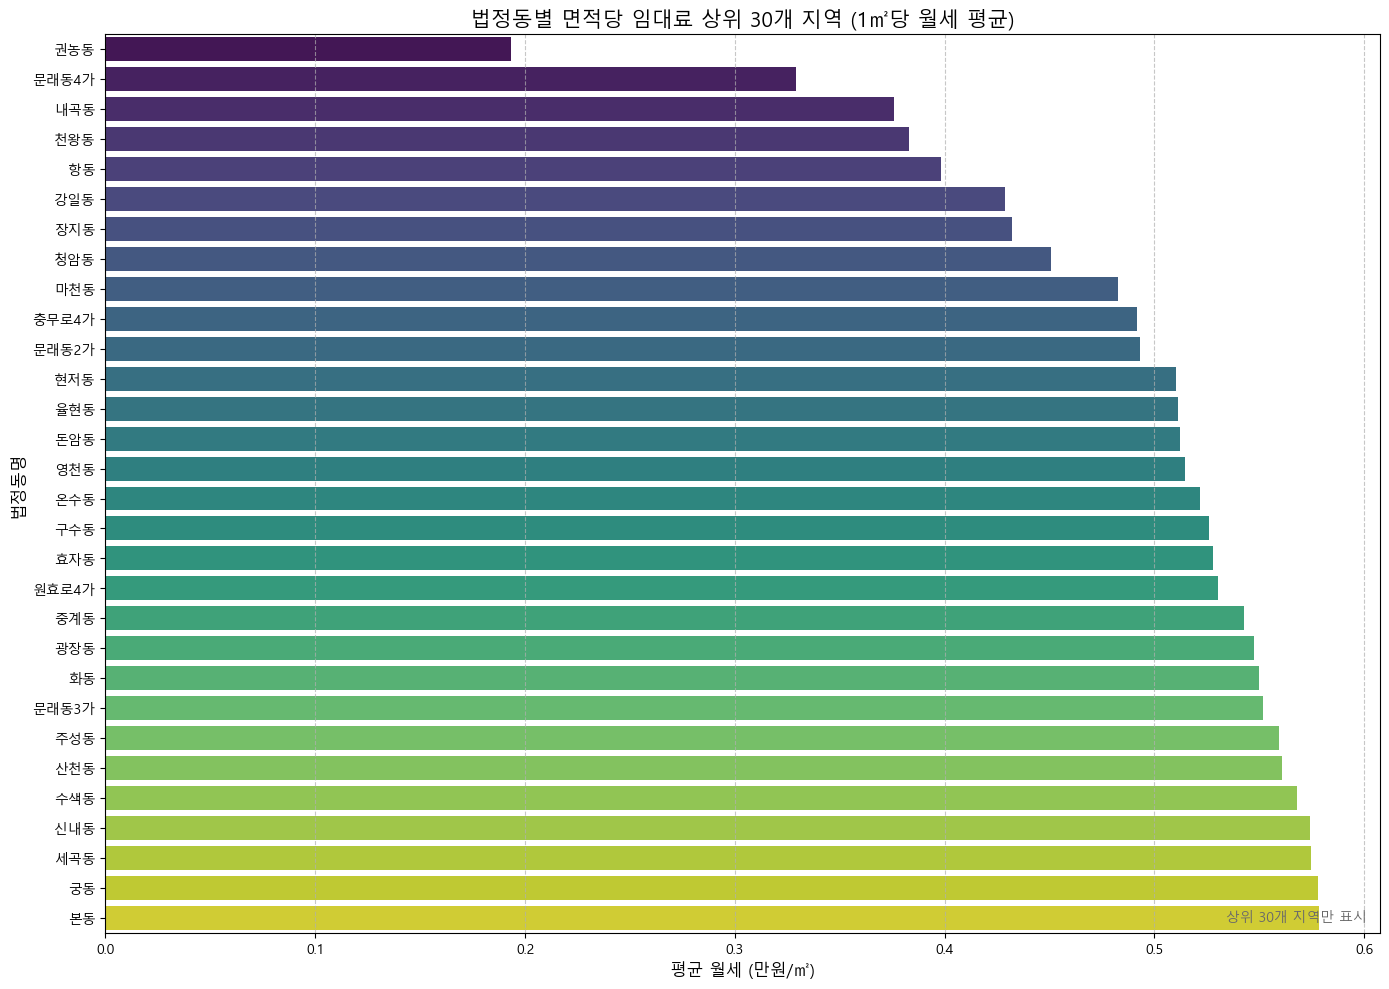


--- 상위 10개 지역명 ---
권농동, 문래동4가, 내곡동, 천왕동, 항동, 강일동, 장지동, 청암동, 마천동, 충무로4가


In [29]:
# 1. 실제 면적 관련 컬럼명 확인
area_cols = [col for col in df.columns if '면적' in col or '㎡' in col or 'area' in col.lower()]

# 2. 면적당 임대료 계산 (면적 컬럼이 있는 경우만)
if area_cols:
    area_col = area_cols[0]  # 첫 번째 면적 컬럼 사용

    # 0으로 나누기 방지
    df['면적당_임대료'] = df['임대료(만원)'].astype(float) / df[area_col].astype(float)
    df['면적당_임대료'] = df['면적당_임대료'].replace([np.inf, -np.inf], np.nan)

    # 이상치(IQR) 제거: 면적당 임대료의 극단값을 걸러냄
    valid_df = df.dropna(subset=['면적당_임대료']).copy()
    q1 = valid_df['면적당_임대료'].quantile(0.25)
    q3 = valid_df['면적당_임대료'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    filtered_df = valid_df[valid_df['면적당_임대료'].between(lower_bound, upper_bound)].copy()

    print(f"✓ 이상치 제거 전 행 수: {len(valid_df)}")
    print(f"✓ 이상치 제거 후 행 수: {len(filtered_df)}")
    print(f"✓ IQR 기준 범위: {lower_bound:.4f} ~ {upper_bound:.4f}")

    # 3. 법정동별 면적당 임대료 평균 계산
    dong_unit_price = filtered_df.groupby('법정동명')['면적당_임대료'].mean().reset_index().sort_values(by='면적당_임대료')

    if len(dong_unit_price) > 0:
        # 4. 시각화
        top_n = 30
        top_unit_price = dong_unit_price.head(top_n).copy()
        top_10_names = top_unit_price.head(10)['법정동명'].tolist()

        plt.figure(figsize=(14, 10))
        plt.rcParams['font.family'] = 'Malgun Gothic'
        plt.rcParams['axes.unicode_minus'] = False

        ax = sns.barplot(data=top_unit_price, y='법정동명', x='면적당_임대료', palette='viridis')
        plt.title(f'법정동별 면적당 임대료 상위 {top_n}개 지역 (1㎡당 월세 평균)', fontsize=15)
        plt.xlabel('평균 월세 (만원/㎡)', fontsize=12)
        plt.ylabel('법정동명', fontsize=12)
        plt.text(0.99, 0.01, f'상위 {top_n}개 지역만 표시', transform=ax.transAxes, ha='right', va='bottom', fontsize=10, color='dimgray')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        # 5. 분석 결과 요약 출력
        print(f"\n--- 상위 10개 지역명 ---")
        print(', '.join(top_10_names))
    else:
        print("✗ 분석 가능한 데이터가 없습니다.")
else:
    print("✗ 면적 관련 컬럼이 없어 이 분석을 건너뜁니다.")

In [32]:
import math
def get_dist(row):
    # 동국대학교 서울캠퍼스 본관 좌표
    DONGGUK_LOC = (37.5583, 127.0002)   
    dong_coords = {
    '권농동': (37.5760, 126.9915), '필동1가': (37.5595, 126.9945), '필동2가': (37.5580, 126.9960),
    '장충동1가': (37.5575, 127.0075), '장충동2가': (37.5510, 127.0030), '신당동': (37.5610, 127.0150),
    '문래동4가': (37.5160, 126.8960), '천왕동': (37.4810, 126.8370), '내곡동': (37.4580, 127.0700),
    '항동': (37.4800, 126.8250), '안암동': (37.5860, 127.0290), '휘경동': (37.5880, 127.0570)
}
    
    dong = row['법정동명']
    if dong in dong_coords:
        lat, lon = dong_coords[dong]
        return haversine_distance(DONGGUK_LOC[0], DONGGUK_LOC[1], lat, lon)
    else:
        return np.nan

In [33]:
# 거리 계산 함수 (Haversine 공식 적용)
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 # 지구 반지름(km)
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * r * np.arctan2(np.sqrt(a), np.sqrt(1-a))

In [ ]:
# 데이터 집계 및 거리 컬럼 생성
dong_stats = df.groupby('법정동명').agg({'임대료(만원)': 'mean', '면적당_임대료': 'mean', '자치구명': 'first'}).reset_index()

# '거리' 컬럼 생성 (각 법정동의 좌표를 찾아 학교와의 거리 계산)
dong_stats['거리'] = dong_stats.apply(get_dist, axis=1)

# 가성비 지수 산출 (Min-Max 스케일링)
scaler = MinMaxScaler()
# 월세와 거리는 모두 '낮을수록' 좋으므로, 스케일링 후 1에서 빼서 점수를 높게 만듭니다.
dong_stats[['월세_s', '거리_s']] = scaler.fit_transform(dong_stats[['임대료(만원)', '거리']])

# 가성비 지수: 월세 점수 60%, 거리 점수 40% 반영
dong_stats['가성비_지수'] = ((1 - dong_stats['월세_s']) * 0.6) + ((1 - dong_stats['거리_s']) * 0.4)

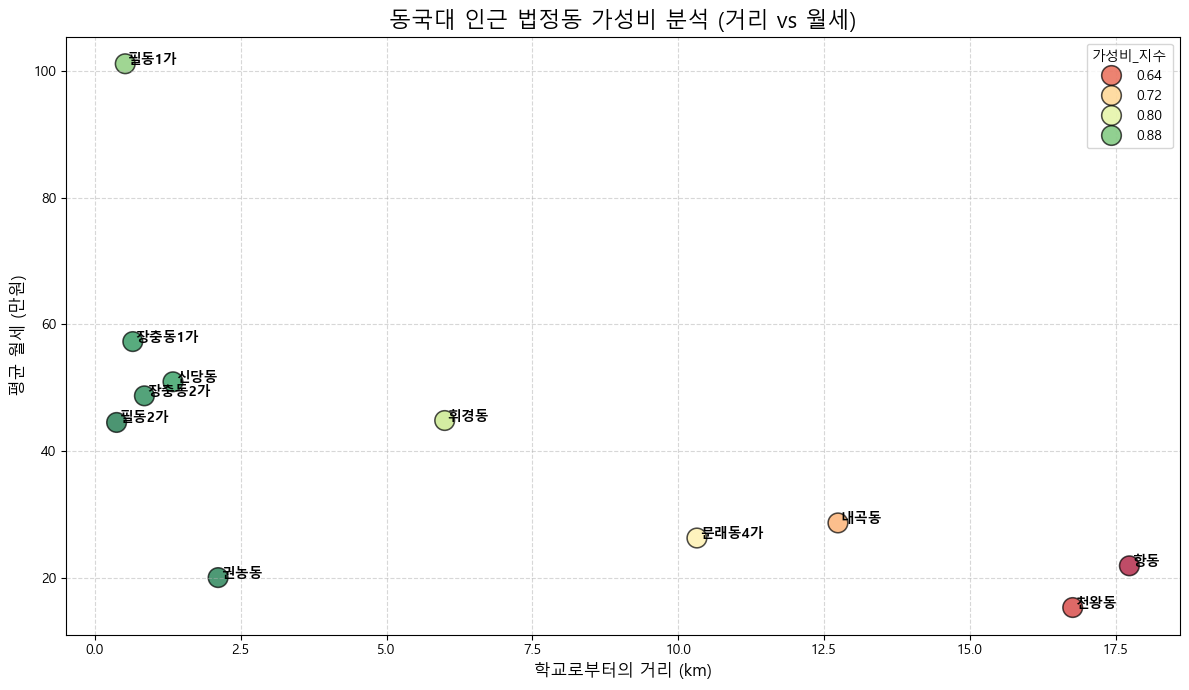


가성비 상위 5개 지역:


KeyError: "['자치구명'] not in index"

In [ ]:
# 4. 시각화
# NaN 값이 있는 행 제거
dong_stats_plot = dong_stats.dropna(subset=['거리', '임대료(만원)'])

plt.figure(figsize=(12, 7))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sns.scatterplot(data=dong_stats_plot, x='거리', y='임대료(만원)', 
                hue='가성비_지수', palette='RdYlGn', s=200, edgecolor='black', alpha=0.7)

# 텍스트 표시 시 .iloc를 사용하여 인덱스 에러 방지
for i in range(len(dong_stats_plot)):
    row = dong_stats_plot.iloc[i]
    plt.text(row['거리'] + 0.05, row['임대료(만원)'], 
             row['법정동명'], fontsize=10, fontweight='bold')

plt.title('동국대 인근 법정동 가성비 분석 (거리 vs 월세)', fontsize=16)
plt.xlabel('학교로부터의 거리 (km)', fontsize=12)
plt.ylabel('평균 월세 (만원)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\n가성비 상위 5개 지역:")
top5 = dong_stats_plot.sort_values('가성비_지수', ascending=False).head(5)
top5_display = top5[['법정동명', '임대료(만원)', '면적당_임대료', '거리', '가성비_지수']].copy()
top5_display = top5_display.round({'임대료(만원)': 1, '면적당_임대료': 3, '거리': 2, '가성비_지수': 4})
print(top5_display.to_string(index=False))

In [36]:
#권농동'은 종로구에 위치해 학교와 가깝고 면적당 임대료가 낮지만, 실제로는 매물이 적거나 노후화된 건물이 많을 수 있습니다. "수치상으로는 1위이나, 실제 주거 환경(신축 여부 등)을 고려한 2차 필터링이 필요함

분석 건수: 78,418건
피어슨 상관계수(보증금-월세): 0.130


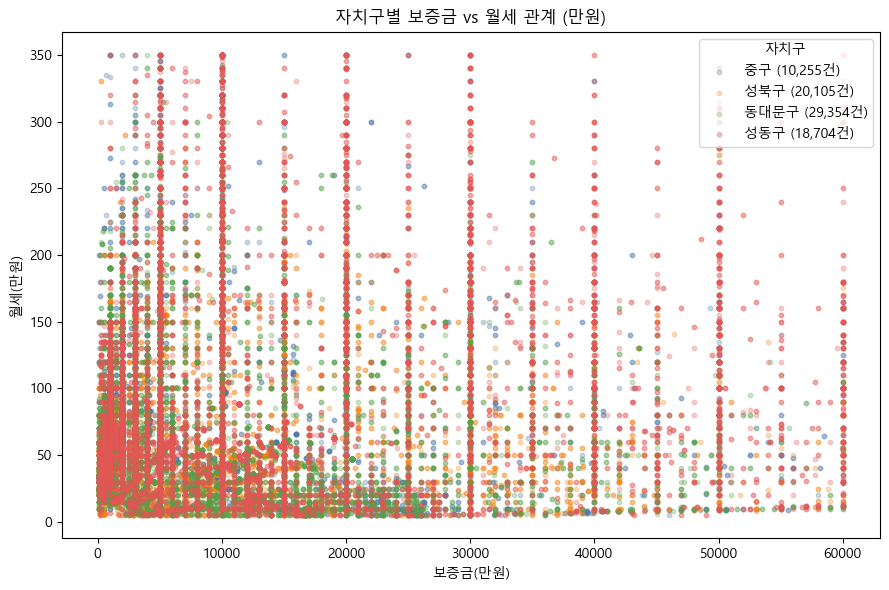

In [56]:
# 보증금 vs 월세 관계 분석 (중구/성북구/동대문구/성동구, 월세)
required_cols_deposit = ['자치구명', '전월세구분', '보증금(만원)', '임대료(만원)']
missing_cols = [c for c in required_cols_deposit if c not in df.columns]

if missing_cols:
    print(f"다음 컬럼이 없어 보증금-월세 분석을 할 수 없습니다: {missing_cols}")
else:
    target = ['중구', '성북구', '동대문구', '성동구']

    rel_df = df[required_cols_deposit].copy()
    rel_df['자치구명'] = rel_df['자치구명'].astype(str).str.strip()
    rel_df['전월세구분'] = rel_df['전월세구분'].astype(str).str.strip()
    rel_df['보증금(만원)'] = pd.to_numeric(rel_df['보증금(만원)'], errors='coerce')
    rel_df['임대료(만원)'] = pd.to_numeric(rel_df['임대료(만원)'], errors='coerce')

    rel_df = rel_df[
        (rel_df['자치구명'].isin(target)) &
        (rel_df['전월세구분'] == '월세')
    ].dropna(subset=['보증금(만원)', '임대료(만원)'])

    # 극단치 영향 완화를 위해 1~99 분위수 범위만 사용
    d_low, d_high = rel_df['보증금(만원)'].quantile([0.01, 0.99])
    r_low, r_high = rel_df['임대료(만원)'].quantile([0.01, 0.99])
    plot_df = rel_df[
        rel_df['보증금(만원)'].between(d_low, d_high) &
        rel_df['임대료(만원)'].between(r_low, r_high)
    ].copy()

    corr = plot_df['보증금(만원)'].corr(plot_df['임대료(만원)'])
    print(f"분석 건수: {len(plot_df):,}건")
    print(f"피어슨 상관계수(보증금-월세): {corr:.3f}")

    # 자치구별 색상 분리 산점도
    district_colors = {
        '중구': '#4C78A8',
        '성북구': '#F58518',
        '동대문구': '#54A24B',
        '성동구': '#E45756'
    }

    plt.figure(figsize=(9, 6))
    for gu in target:
        gu_df = plot_df[plot_df['자치구명'] == gu]
        if not gu_df.empty:
            plt.scatter(
                gu_df['보증금(만원)'],
                gu_df['임대료(만원)'],
                s=10,
                alpha=0.28,
                color=district_colors[gu],
                label=f"{gu} ({len(gu_df):,}건)"
            )

    plt.title('자치구별 보증금 vs 월세 관계 (만원)')
    plt.xlabel('보증금(만원)')
    plt.ylabel('월세(만원)')
    plt.legend(title='자치구', frameon=True)
    plt.tight_layout()
    plt.show()

보증금 구간별 월세 중앙값
                보증금구간   보증금중앙값  월세중앙값    표본수
0     (99.999, 500.0]    500.0   45.0  12843
1     (500.0, 1000.0]   1000.0   65.0  19442
2    (1000.0, 2700.0]   2000.0   65.0   7489
3    (2700.0, 4648.0]   3000.0   60.0   7953
4    (4648.0, 7000.0]   5000.0   83.0   8392
5   (7000.0, 11400.0]  10000.0   76.0   7627
6  (11400.0, 21000.0]  15900.0   44.0   7900
7  (21000.0, 60000.0]  31500.0   70.0   7898


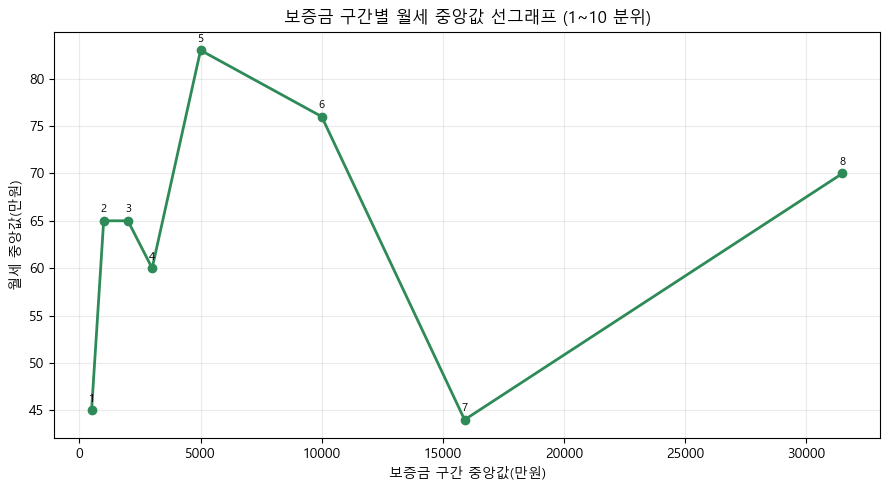

In [38]:
# 보증금 구간별 월세 중앙값 선그래프
required_cols_bin = ['자치구명', '전월세구분', '보증금(만원)', '임대료(만원)']
missing_cols_bin = [c for c in required_cols_bin if c not in df.columns]

if missing_cols_bin:
    print(f"다음 컬럼이 없어 구간 분석을 할 수 없습니다: {missing_cols_bin}")
else:
    target = ['중구', '성북구', '동대문구', '성동구']

    bin_df = df[required_cols_bin].copy()
    bin_df['자치구명'] = bin_df['자치구명'].astype(str).str.strip()
    bin_df['전월세구분'] = bin_df['전월세구분'].astype(str).str.strip()
    bin_df['보증금(만원)'] = pd.to_numeric(bin_df['보증금(만원)'], errors='coerce')
    bin_df['임대료(만원)'] = pd.to_numeric(bin_df['임대료(만원)'], errors='coerce')

    bin_df = bin_df[
        (bin_df['자치구명'].isin(target)) &
        (bin_df['전월세구분'] == '월세')
    ].dropna(subset=['보증금(만원)', '임대료(만원)'])

    # 극단치 제외 후 보증금을 10분위 구간으로 나눔
    d_low, d_high = bin_df['보증금(만원)'].quantile([0.01, 0.99])
    bin_df = bin_df[bin_df['보증금(만원)'].between(d_low, d_high)].copy()

    bin_df['보증금구간'] = pd.qcut(bin_df['보증금(만원)'], q=10, duplicates='drop')

    line_df = (
        bin_df.groupby('보증금구간', observed=False)
        .agg(보증금중앙값=('보증금(만원)', 'median'), 월세중앙값=('임대료(만원)', 'median'), 표본수=('임대료(만원)', 'count'))
        .reset_index(drop=False)
        .sort_values('보증금중앙값')
    )

    print('보증금 구간별 월세 중앙값')
    print(line_df[['보증금구간', '보증금중앙값', '월세중앙값', '표본수']])

    plt.figure(figsize=(9, 5))
    plt.plot(line_df['보증금중앙값'], line_df['월세중앙값'], marker='o', linewidth=2, color='#2E8B57')
    for i, row in line_df.iterrows():
        plt.annotate(str(i + 1), (row['보증금중앙값'], row['월세중앙값']), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)

    plt.title('보증금 구간별 월세 중앙값 선그래프 (1~10 분위)')
    plt.xlabel('보증금 구간 중앙값(만원)')
    plt.ylabel('월세 중앙값(만원)')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [39]:
# 1. 보증금 수준 정의 (사용자 맞춤형 필터링)
# 예: 보증금이 적은 학생(Light), 보증금 여유가 있는 학생(Premium)
def get_recommendation_by_deposit(deposit_limit):
    # 입력받은 보증금 한도 내의 데이터만 필터링
    filtered_df = df[df['보증금(만원)'] <= deposit_limit].copy()
    
    if filtered_df.empty:
        return "해당 보증금 범위 내에 매물이 없습니다."

    # 법정동별 집계 (월세, 면적당 임대료)
    rec_stats = filtered_df.groupby('법정동명').agg({
        '임대료(만원)': 'mean',
        '면적당_임대료': 'mean'
    }).reset_index()

    # 거리 데이터 결합 (기존에 정의한 get_dist 함수 활용)
    rec_stats['거리'] = rec_stats.apply(get_dist, axis=1)

    # 지수 산출 (Min-Max 스케일링)
    scaler = MinMaxScaler()
    rec_stats[['월세_s', '면적_s', '거리_s']] = scaler.fit_transform(rec_stats[['임대료(만원)', '면적당_임대료', '거리']])
    
    # 통합 가성비 지수 (월세 30%, 면적 40%, 거리 30%)
    rec_stats['추천_지수'] = ((1 - rec_stats['월세_s']) * 0.3 + 
                            (1 - rec_stats['면적_s']) * 0.4 + 
                            (1 - rec_stats['거리_s']) * 0.3)
    
    return rec_stats.sort_values('추천_지수', ascending=False).head(3)

# 2. 실행 예시
print("=== [Case 1] 보증금 1,000만원 이하 학생을 위한 TOP 3 ===")
display(get_recommendation_by_deposit(1000))

print("\n=== [Case 2] 보증금 5,000만원까지 가능한 학생을 위한 TOP 3 ===")
display(get_recommendation_by_deposit(5000))

=== [Case 1] 보증금 1,000만원 이하 학생을 위한 TOP 3 ===


,법정동명,임대료(만원),면적당_임대료,거리,월세_s,면적_s,거리_s,추천_지수
356,필동2가,65.627907,1.881449,0.371722,0.049563,0.220242,0.000000,0.897034
310,장충동2가,55.398496,2.400773,0.848421,0.036089,0.293142,0.027453,0.863680
203,신당동,61.037125,2.596333,1.338667,0.043516,0.320594,0.055687,0.842001



=== [Case 2] 보증금 5,000만원까지 가능한 학생을 위한 TOP 3 ===


,법정동명,임대료(만원),면적당_임대료,거리,월세_s,면적_s,거리_s,추천_지수
367,필동2가,70.403226,1.804670,0.371722,0.068256,0.177920,0.000000,0.908355
317,장충동2가,56.400356,2.160223,0.848421,0.046782,0.238755,0.027453,0.882227
207,신당동,78.257370,2.532530,1.338667,0.080300,0.302457,0.055687,0.838221


In [ ]:
#Further Analysis: 가용 예산별 맞춤 추천